# DECI project : `Ford gobike` 

## *explantory data analysis*

"The dataset used in this analysis comes from Ford GoBike, a bike-sharing service in the San Francisco Bay Area. It includes information about individual rides, such as trip duration, start and end stations, user types (Subscriber vs. Customer), and rider demographics. The goal of this analysis is to explore trends in bike usage, identify common rider behaviors, and detect any anomalies in the data."

In [1]:
import pandas as pd              # for data manipulation
import numpy as np               # for numerical computation
import matplotlib.pyplot as plt  # for data visualization
import seaborn as sns            # for data visualization

In [2]:
df=pd.read_csv('fordgobike-tripdata-clean.csv') # load the dataset
df.head() # display the first 5 rows of the dataset

,duration_sec,start_time,end_time,user_type,member_birth_year,member_gender,bike_share_for_all_trip,year-month,age,age_group
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,Customer,1984.000000,Male,No,2019-02,35.000000,30 - 39
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,Customer,1984.806437,Other,No,2019-02,34.193563,30 - 39
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,Customer,1972.000000,Male,No,2019-02,47.000000,40 - 49
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,Subscriber,1989.000000,Other,No,2019-02,30.000000,30 - 39
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,Subscriber,1974.000000,Male,Yes,2019-02,45.000000,40 - 49


using needed functions for ploting

In [3]:
def plot_univariate(df, col, plot_type='hist', title='', xlabel='', ylabel='', log_scale=False, bins=None):
    """ 
    Function to generate univariate plots (histogram or bar chart).
    
    Parameters:
        df (DataFrame): The dataset containing the column to plot.
        col (str): The column to visualize.
        plot_type (str): Type of plot ('hist' for histogram, 'bar' for bar chart).
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to use a log scale on the y-axis.
        bins (array-like, optional): Custom bin edges for histograms.
    """
    plt.figure(figsize=(10, 5))

    if plot_type == 'hist':
        plt.hist(df[col], bins=bins, edgecolor='black') if bins is not None else plt.hist(df[col], edgecolor='black')
    elif plot_type == 'bar':
        df[col].value_counts().sort_index().plot(kind='bar', edgecolor='black')
    else:
        raise ValueError("Invalid plot_type. Use 'hist' or 'bar'.")

    if log_scale:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


In [4]:
def plot_bivariate(df, x_col, y_col=None, plot_type='scatter', title='', xlabel='', ylabel='', log_scale=False, hue=None, filter_y=None):
    """ 
    Function to generate bivariate plots (scatter, boxplot, or bar).
    
    Parameters:
        df (DataFrame): The dataset containing the columns to plot.
        x_col (str): The column for the x-axis.
        y_col (str, optional): The column for the y-axis (required for scatter and boxplot).
        plot_type (str): Type of plot ('scatter', 'box', 'bar').
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to use a log scale on the y-axis.
        hue (str, optional): Column for color grouping in bar plots.
        filter_y (float, optional): Upper limit to filter y_col values.
    """
    plt.figure(figsize=(10, 5))

    if filter_y and y_col:
        df = df[df[y_col] <= filter_y]

    if plot_type == 'scatter':
        sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5)
    elif plot_type == 'box':
        sns.boxplot(data=df, x=x_col, y=y_col)
    elif plot_type == 'bar':
        sns.countplot(data=df, x=x_col, hue=hue)
    else:
        raise ValueError("Invalid plot_type. Use 'scatter', 'box', or 'bar'.")

    if log_scale:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


### What is the distribution of trip durations in the Ford GoBike dataset?

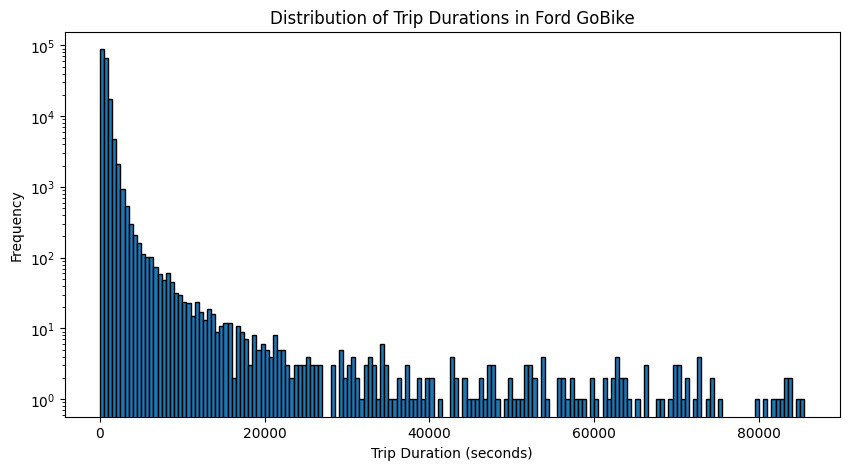

In [5]:
# Define custom bins for the histogram
bins = np.arange(0, df['duration_sec'].max() + 500, 500)
plot_univariate(df, col='duration_sec', plot_type='hist', bins=bins, log_scale=True,
                title='Distribution of Trip Durations in Ford GoBike',
                xlabel='Trip Duration (seconds)', ylabel='Frequency')

In this analysis, we examine the distribution of trip durations in the Ford GoBike dataset using a histogram. The data exhibits a right-skewed distribution, with a large number of short trips and a few extremely long trips. To enhance visibility, we apply a logarithmic scale on the y-axis, allowing us to better observe trends in the dataset.

The results show that most trips last under 1,000 seconds (~16 minutes), reinforcing the idea that bike-sharing is primarily used for short, quick rides. However, there are some outliers exceeding 80,000 seconds (~22 hours), which could indicate system errors, potential misuse, or unique ride behaviors. Further investigation is needed to determine whether these long trips are valid or should be filtered for accurate insights.

### What age group uses bikes the most?

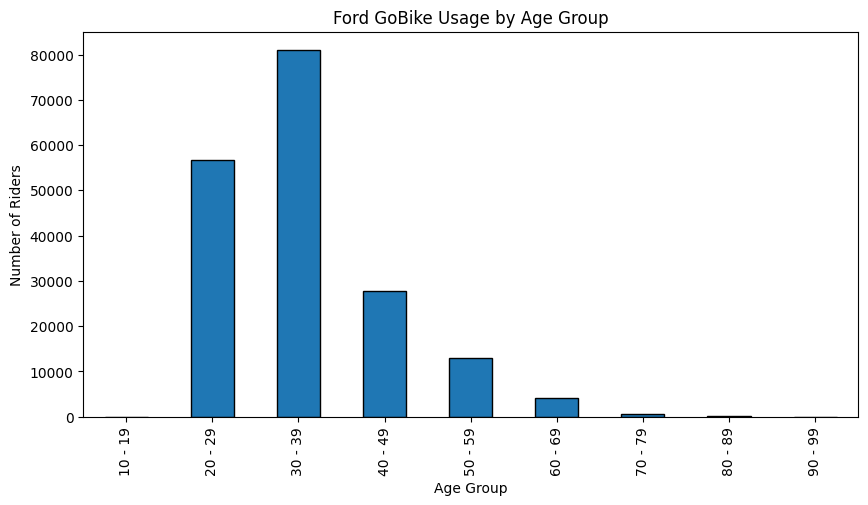

In [6]:
plot_univariate(df, col='age_group', plot_type='bar',
                title='Ford GoBike Usage by Age Group',
                xlabel='Age Group', ylabel='Number of Riders')

In this analysis, we explore bike usage across different age groups to identify which demographic rides the most. The bar chart reveals that bike-sharing is dominated by riders aged 20-39, with the 30-39 age group having the highest number of users, followed closely by 20-29-year-olds.

After age 40, bike usage gradually declines, with a sharp drop-off after 60. This suggests that bike-sharing is most popular among young and middle-aged adults, likely due to factors such as commuting needs, physical ability, and convenience. Understanding these trends can help optimize bike-sharing services to better cater to different age groups. 

### Do trip duration patterns differ by user type and day of the week?

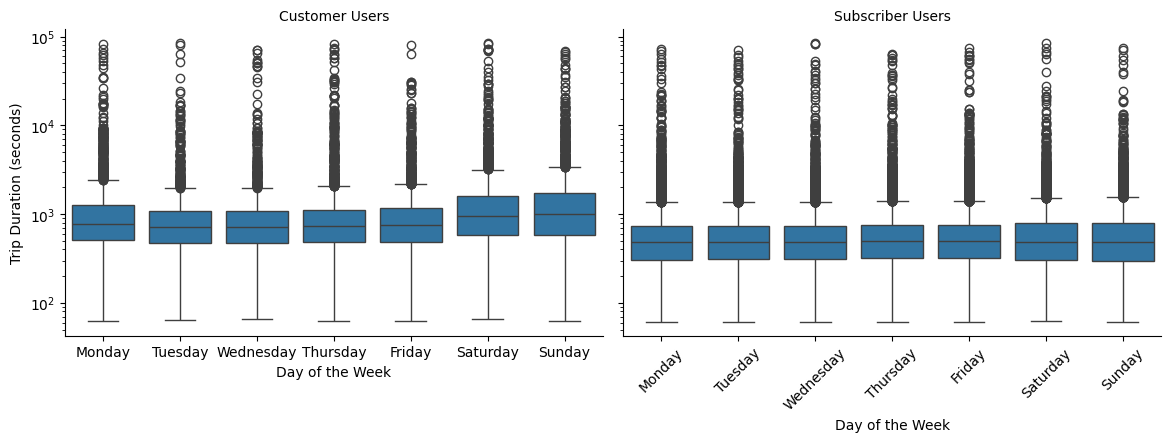

In [7]:
# Convert start_time to day of the week if not already
df['start_day'] = pd.to_datetime(df['start_time']).dt.day_name()

# Set up a FacetGrid with user type across columns
g = sns.FacetGrid(df, col="user_type", height=4, aspect=1.5, margin_titles=True)

# Map a boxplot for trip duration across days of the week
g.map(sns.boxplot, "start_day", "duration_sec", order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Adjust labels and titles
g.set_axis_labels("Day of the Week", "Trip Duration (seconds)")
g.set_titles(col_template="{col_name} Users")
plt.xticks(rotation=45) 
plt.yscale("log")  # Log scale to handle skewed data
plt.show()

This faceted box plot illustrates how trip duration varies across different days of the week for both customers and subscribers. The data reveals that customers generally have longer trip durations compared to subscribers, as indicated by their higher median values and wider spread in the box plots.

This suggests that customers may use the service for leisure or occasional trips, while subscribers take shorter, more consistent trips, likely for commuting purposes. Interestingly, trip durations remain fairly stable throughout the week for both user types, indicating that weekday and weekend riding patterns are similar. Understanding these trends can help optimize bike-sharing services to meet user needs. 

## How does bike usage vary between different user types (Subscriber vs Customer) across age groups?

Bike usage varies across different age groups and user types, with the highest number of riders in the 30-39 age group, followed closely by those aged 20-29. This suggests that bike-sharing services are most popular among young adults.

Subscribers make up the majority of riders in all age groups, indicating a strong preference for membership-based access over one-time rentals. This trend is especially noticeable among younger users. As age increases, overall ridership declines, highlighting that bike-sharing is primarily favored by younger adults. Recognizing these usage patterns can help optimize bike-sharing services to better meet the needs of different demographics

## How does trip duration vary between different user types (Subscribers vs. Customers)?
Trip durations show clear differences between Subscribers and Customers. On average, Customers take longer trips compared to Subscribers, as seen in their higher median trip duration. Additionally, Customers have a wider range of trip durations, indicating greater variability in how long they ride.

Subscribers, on the other hand, tend to have shorter and more consistent trip lengths, suggesting that they primarily use the service for commuting or routine travel. Meanwhile, Customers likely take longer, less frequent trips, possibly for leisure or tourism. Despite these trends, both user groups show occasional long-duration rides, which could be due to outliers or special circumstances.

## How does trip duration vary with age?
This analysis examines how trip duration varies across different age groups. The data shows that most trips are relatively short, clustering under 5,000 seconds (~83 minutes). However, younger riders, particularly those in their 20s and 30s, are more likely to take longer trips, with some extending beyond 20,000 seconds (~5.5 hours).

As age increases, trip durations become shorter and more consistent, suggesting that older riders prefer quicker trips. Additionally, the presence of outliers, particularly users with ages over 100, indicates possible data entry errors. Cleaning the data to remove unrealistic ages and extreme trip durations could enhance the accuracy of future analyses.

Overall, younger riders tend to take longer and more frequent trips, while older riders opt for shorter, more predictable rides.

## How do age, trip duration, and user type interact in the dataset? Are there noticeable trends based on user type?
This analysis explores the relationship between age, trip duration, and user type. The data reveals that most trips are taken by users aged 20 to 40, with ridership gradually declining as age increases. Additionally, subscribers consistently outnumber customers across all age groups, suggesting that most users prefer a membership-based system over occasional rentals.

In terms of trip duration, short trips are the most common, with a few outliers extending to extremely long durations. Riders aged 60+ participate less frequently and tend to take shorter trips, further reinforcing the trend that bike-sharing is primarily popular among younger adults. While both user types exhibit similar patterns, customers show slightly more variation in their trip durations.

Overall, this analysis highlights that bike-sharing is dominated by younger subscribers taking short, frequent rides, while older users and customers show more variability in their usage patterns.

# summary
This analysis provides insights into bike usage trends, trip durations, and user demographics within the Ford GoBike system

* Trip Duration Distribution: The majority of trips are relatively short, with most lasting under 1,000 seconds (~16 minutes). However, a few extremely long trips suggest possible outliers, system errors, or misuse.

* Age and Bike Usage: Younger riders (20-39 years old) dominate bike usage, particularly those in their 30s. Ridership declines after 40, with very few riders aged 60+, indicating that bike-sharing is most popular among younger adults.

* User Type Differences: Subscribers significantly outnumber customers in every age group. Subscribers tend to take shorter and more consistent trips, likely for commuting, while customers have longer and more varied trip durations, possibly for leisure or tourism.

* Trip Duration and Age Relationship: Younger riders, especially those in their 20s and 30s, take longer trips, while older riders prefer shorter, more consistent rides. Some unrealistic age values (100+) suggest data entry errors.

* Trip Duration by Day of the Week: Customers generally take longer trips than subscribers across all days of the week. However, trip durations remain relatively stable, indicating that usage patterns do not drastically change between weekdays and weekends.

* Interaction of Age, Trip Duration, and User Type: The majority of trips are short, especially among subscribers. Customers show more variation in trip durations, while older riders participate less frequently and prefer shorter rides.

## Key Takeaways:
* Bike-sharing is most popular among younger adults (20-39 years old).
* Subscribers take shorter, more consistent trips, likely for commuting.

* Customers take longer, more varied trips, possibly for leisure.
* Older riders (60+) use the service less and prefer shorter trips.
* Outliers in trip duration and unrealistic age values indicate a need for data cleaning.

This analysis provides a comprehensive view of who uses Ford GoBike, how they use it, and how trip duration varies by different factors, offering valuable insights for service improvements and future research. 